In [34]:
import  pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [26]:
df=pd.read_csv('heart.csv')

In [27]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [28]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [29]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

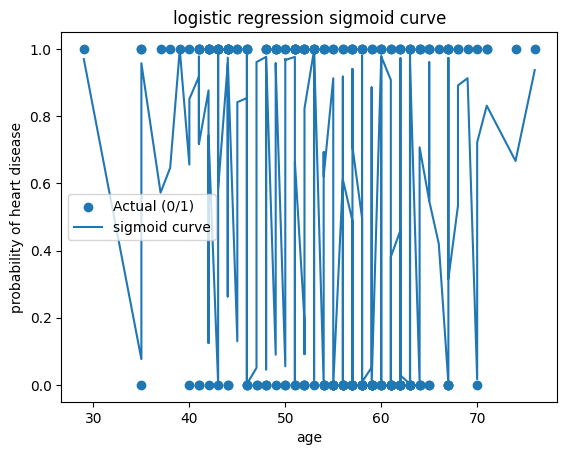

In [43]:
import numpy as np
import matplotlib.pyplot as plt
#age feature
x_age=X_test["age"].values.reshape(-1,1)
#model probability output (sigmoid)
y_prob=model.predict_proba(X_test)[:,1]

#sorting for smooth curve
sorted_idx=np.argsort(x_age[:,0])
x_age_sorted=x_age[sorted_idx]
y_prob_sorted=y_prob[sorted_idx]

plt.figure()
plt.scatter(x_age, y_test, label="Actual (0/1)")
plt.plot(x_age_sorted, y_prob_sorted, label="sigmoid curve")
plt.title("logistic regression sigmoid curve")
plt.xlabel("age")
plt.ylabel("probability of heart disease")
plt.legend()
plt.show()

In [30]:
y_pred=model.predict(X_test)

In [31]:
accuracy=accuracy_score(y_test,y_pred)
print(f"accuracy: {accuracy:.2f}")

accuracy: 0.80


In [37]:
##trying with random forest 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5)
rf_model.fit(X_train,y_train)
rf_y_pred=rf_model.predict(X_test)
rf_accuracy=accuracy_score(y_test,rf_y_pred)
print(f"Random Forest accuracy: {rf_accuracy:.2f}")

Random Forest accuracy: 0.88


In [38]:
#accuracy bhot jayeda hai random forest ki shyd ye ovrfit ho skta hai to check krenge test or train ki accuracy
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9597560975609756
Test Accuracy: 0.8829268292682927


In [44]:
#feautre importance
importances=rf_model.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({
    "feature":feature_names,
    "importance":importances
    })

feature_importance_df=feature_importance_df.sort_values(by="importance",ascending=False)
print(feature_importance_df)

     feature  importance
12      thal    0.160226
11        ca    0.154452
2         cp    0.151295
9    oldpeak    0.132979
7    thalach    0.113307
10     slope    0.057775
8      exang    0.055265
0        age    0.051784
3   trestbps    0.044548
4       chol    0.043989
1        sex    0.022520
6    restecg    0.007355
5        fbs    0.004505


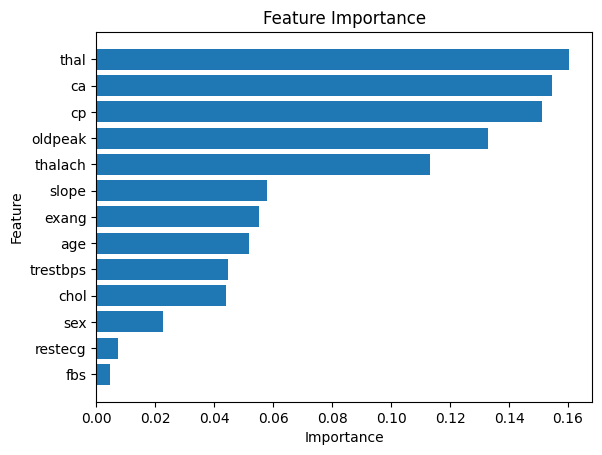

In [45]:
plt.figure()
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis() #tpofeature upar dikhe
plt.show()

In [52]:
# sample patient data
input_data = np.array([[55, 1, 2, 140, 250, 0, 1, 150, 0, 1.5, 1, 0, 2]])

In [53]:
prediction = rf_model.predict(input_data)

if prediction[0] == 1:
    print("Heart Disease Detected ")
else:
    print("No Heart Disease ")

prob = rf_model.predict_proba(input_data)
print("Probability:", prob)

Heart Disease Detected 
Probability: [[0.2344385 0.7655615]]


/home/adi/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/adi/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
